# Is a jet-loving CEO a governance short? ✈️
### The corporate jet as a sell signal — a beautiful story, tested

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Governance_discount%3F: Misattributed](https://img.shields.io/badge/Governance_discount%3F-Misattributed-8b949e?style=flat-square)

In 2006 a finance professor named David Yermack noticed something delicious. The moment a company first admits, in the fine print of its proxy, that the CEO flies the corporate jet for **personal** trips, the stock tends to **lag the market by about 4% a year** afterward. The jet, he argued, is a *tell*: a CEO helping themselves to the company plane is a CEO who might be helping themselves to a lot of things. Cue the obvious trade — **short the flyers, buy the penny-pinchers**, and pocket the governance discount.

It's the kind of idea you *want* to be true. So we built it: a labelled list of ~24 large-caps split into **jet-loving CEOs** (Ellison, Musk, Zuckerberg, Adelson, Wynn, Jeffries…) and **frugal ones** (Buffett, Costco, Walmart, Texas Instruments…), and we ran the long/short. The answer is a great little lesson in *why the sign being right doesn't make the trade real.*

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the market-model alpha, the betting-against-beta confound spelled out? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real governance-perk databases aren't free, so we **hardcode a transparent table** from proxy filings and press coverage (and the heavy/frugal call is ours — a judgement at the edges). And the most infamous jet abusers — Tyco, WorldCom, Enron — *went bankrupt and vanished from the tape*, which, as we'll see, biases the test **against** the very thing we're looking for. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from corporate_jet_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, FIRMS = data.load_real()
    PANEL = st.long_short_panel(PRICES, FIRMS, min_names=4)
    S = st.summarize(PANEL)
else:
    PRICES = FIRMS = PANEL = S = None
print("real price cache present:", HAVE_REAL,
      "| panel months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_firms': 24, 'n_heavy': 12, 'n_low': 12, 'fingerprint': 'ad201b5ed46c', 'n_months': 186, 'start': '2011-01', 'end': '2026-06', 'ls_ann': 2.11, 'ls_hac_t': 0.47, 'ls_naive_t': 0.48, 'ls_sharpe': 0.12, 'ls_lags': 4, 'heavy_x_ann': -0.34, 'low_x_ann': 1.76, 'alpha_ann': 8.81, 'alpha_t': 2.1, 'ls_beta': -0.45, 'heavy_beta': 1.31, 'low_beta': 0.87, 'cagr_low': 16.15, 'cagr_spy': 14.17, 'cagr_heavy': 12.19, 'ex_heavy_x': -3.83, 'ex_low_x': 1.76, 'ex_ls_ann': 5.8, 'ex_hac_t': 1.08, 'ex_alpha_ann': 12.08, 'ex_alpha_t': 2.22, 'gross_ann': 2.11, 'cost_ann': 0.24, 'borrow_ann': 0.5, 'net_ann': 1.36, 'winners': [('TSLA', 53.5), ('GOOGL', 10.1), ('META', 7.4), ('ANF', 4.7), ('GE', 1.9), ('ORCL', 1.6)], 'laggards': [('IEP', -14.1), ('CMCSA', -7.5), ('OXY', -5.7), ('LVS', -5.3), ('WYNN', -4.8), ('DIS', -3.9)], 'syn': [(0.0, -1.17, -0.49), (-80.0, 8.76, 3.53)]}


real price cache present: True | panel months: 186


## The answer first

| Question | Answer |
|---|---|
| Did the frugal firms beat the flyers? | **Yes, actually.** Over 2011–2026 the frugal basket compounded at **16.1%/yr** vs the flyers' **12.2%** — about the ~4pp gap Yermack found. The *sign* is real. |
| So the short works? | **No.** Month to month that gap is **pure noise** (*t* = **0.47**, where you need 2). A net **+1.4%/yr** you can't distinguish from luck. |
| But there's a *significant* number in here… | **There is — and it's a trick.** The one stat that clears the bar (**+8.8%/yr** 'alpha') comes entirely from the long/short being **short high-risk stocks and long low-risk stocks** — a well-known low-volatility premium, *not* anything about jets. |
| What breaks it? | **One Tesla.** The single best-performing 'flyer' (Elon Musk's Tesla, **+54%/yr** vs the market) single-handedly drags the short basket up. The surviving jet-lovers are disproportionately founder-run *winners*. |

> The corporate jet is a real *correlate* of trouble — but on a tradable tape it's a correlate of **high-beta founder-growth stocks**, not an independent edge. Right sign, wrong reason, no trade.

## 1 · The claim

> *"When a CEO starts flying the company jet on personal time, it's a red flag — those firms underperform. Short the flyers, own the frugal ones."*

This is a real, cited academic finding — Yermack's *Flights of Fancy* (2006) — not a message-board myth, which is exactly why it's worth taking seriously. The logic is clean: personal jet use is a **visible, disclosed symptom** of the deeper thing you can't see (weak boards, entrenched managers, empire-building). If the symptom is public and the disease is real, the stock should carry a discount you can trade. We'll test the strongest version: a long/short that's **long the frugal, short the flyers**, and see if the spread is anything more than the market's mood.

## 2 · So what?

If a *disclosed, public* perk predicted a 4%/yr underperformance, that would be genuinely shocking — it would mean the market ignores a red flag sitting in plain sight in every proxy statement, year after year. That's a big claim about market efficiency, and a standing money machine. But there's a catch the story never mentions: a jet-loving CEO is rarely *just* a jet-loving CEO. They tend to be **founders**, **empire-builders**, **high-conviction growth bosses** — and those traits come with a stock profile (high beta, high growth) that has its own, totally separate, expected return. So the real question isn't "do flyers underperform?" but "do they underperform **for the governance reason**, *after* you strip out the fact that they're high-octane growth stocks?" That's where the story usually dies.

## 3 · How would we even know?

We hardcode **~24 large-caps** (as-of 2026-06-30; **12** flagged jet-heavy, **12** frugal peers) and run a monthly **long/short**:

1. **Two baskets.** Equal-weight the frugal names, equal-weight the flyers. Each flyer only enters the short **after** its jet perk is public (no cheating with hindsight).
2. **Long/short = frugal − flyers**, measured *in excess of the market* so we're not just paid for stocks going up. Positive = Yermack was right.
3. **Judge it honestly.** A Newey-West *t*-stat (the noise-robust kind) on the monthly spread. And — the decisive move — a **market-model** check that asks: is this 'edge' just **beta**? Then costs, short-borrow, and a stress test dropping the mega-cap winners.

**What would make us say 'mirage':** if the tradable spread can't clear *t* = 2, or if the only significant number vanishes once we account for the baskets' different riskiness.

## 4 · The teardown — let's actually look

**First, the part that flatters the story.** Here's a dollar invested in each basket (dividends reinvested) over the sample. The frugal basket really does finish ahead of the flyers — and even ahead of the S&P. The believers get their headline.

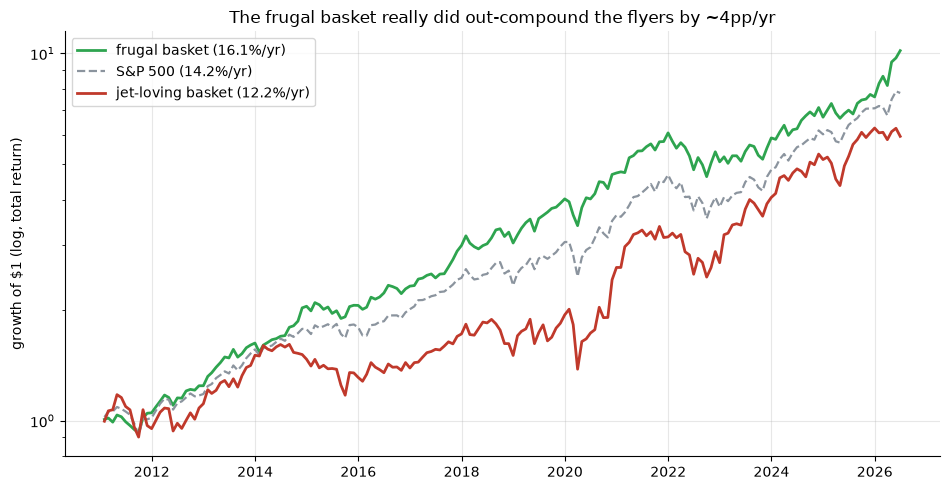

frugal 16.1%/yr  >  S&P 14.2%/yr  >  flyers 12.2%/yr


In [2]:
if HAVE_REAL:
    hb = st.basket_returns(PRICES, FIRMS, heavy=True).reindex(PANEL.index).fillna(0)
    lb = st.basket_returns(PRICES, FIRMS, heavy=False).reindex(PANEL.index).fillna(0)
    mk = st.monthly_returns(PRICES)['SPY'].reindex(PANEL.index).fillna(0)
    cl, ch, cm = (1+lb).cumprod(), (1+hb).cumprod(), (1+mk).cumprod()
    idx = PANEL.index
else:
    idx = np.arange(R['n_months'])
    cl = (1+R['cagr_low']/100/12)**np.arange(R['n_months'])
    ch = (1+R['cagr_heavy']/100/12)**np.arange(R['n_months'])
    cm = (1+R['cagr_spy']/100/12)**np.arange(R['n_months'])
fig, ax = plt.subplots(figsize=(9.6, 5.0))
ax.plot(idx, cl, c=GREEN, lw=2, label=f"frugal basket ({R['cagr_low']:.1f}%/yr)")
ax.plot(idx, cm, c=GREY, lw=1.6, ls='--', label=f"S&P 500 ({R['cagr_spy']:.1f}%/yr)")
ax.plot(idx, ch, c=RED, lw=2, label=f"jet-loving basket ({R['cagr_heavy']:.1f}%/yr)")
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log, total return)')
ax.set_title('The frugal basket really did out-compound the flyers by ~4pp/yr'); ax.legend()
plt.tight_layout(); plt.show()
print(f"frugal {R['cagr_low']:.1f}%/yr  >  S&P {R['cagr_spy']:.1f}%/yr  >  flyers {R['cagr_heavy']:.1f}%/yr")

So far, so Yermack: **16.1%/yr** frugal vs **12.2%/yr** flyers, the right sign and roughly the right size. If we stopped here we'd write it up as a win. But a compounding chart hides all the wiggles — and the wiggles are where the truth is.

**Now the honest test — is the monthly spread anything but noise?** We take the long/short (frugal minus flyers, in excess of the market) *month by month* and ask whether its average is reliably above zero. Here's the running total of that spread, with the *t*-stat.

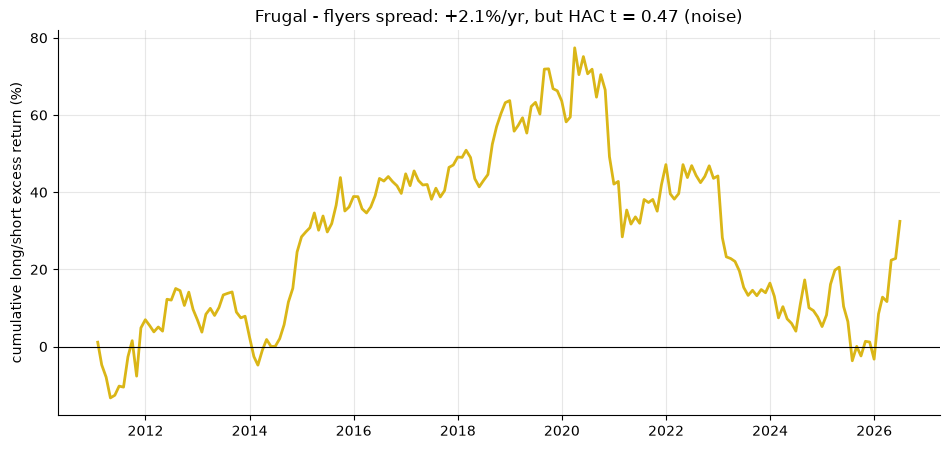

long/short +2.1%/yr | HAC t = 0.47 -> you need |t|>=2, this is a coin flip


In [3]:
if HAVE_REAL:
    ls = PANEL['ls']; t = S['ls_hac_t']; ann = S['ls_mean_ann']*100
    cum = ls.cumsum()*100; idx = PANEL.index
else:
    rng=np.random.default_rng(745); ls=rng.normal(R['ls_ann']/100/12, 0.03, R['n_months'])
    t=R['ls_hac_t']; ann=R['ls_ann']; cum=np.cumsum(ls)*100; idx=np.arange(R['n_months'])
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.plot(idx, cum, c=AMBER, lw=2)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('cumulative long/short excess return (%)')
ax.set_title(f'Frugal - flyers spread: {ann:+.1f}%/yr, but HAC t = {t:.2f} (noise)')
plt.tight_layout(); plt.show()
print(f'long/short {ann:+.1f}%/yr | HAC t = {t:.2f} -> you need |t|>=2, this is a coin flip')

A wandering line that ends up mildly positive — and a *t*-stat of **0.47**. That's not an edge; that's a random walk that happened to drift up. The ~4pp compounding gap is **real but statistically silent**: too few names, too much month-to-month scatter. The believers' headline survives the eye and dies at the *t*-test.

**Where the whole story breaks — one chart.** Here's every flyer's return *versus the market*. The thesis says these should mostly be red (underperformers). Most are — but look at the one enormous green bar on the right.

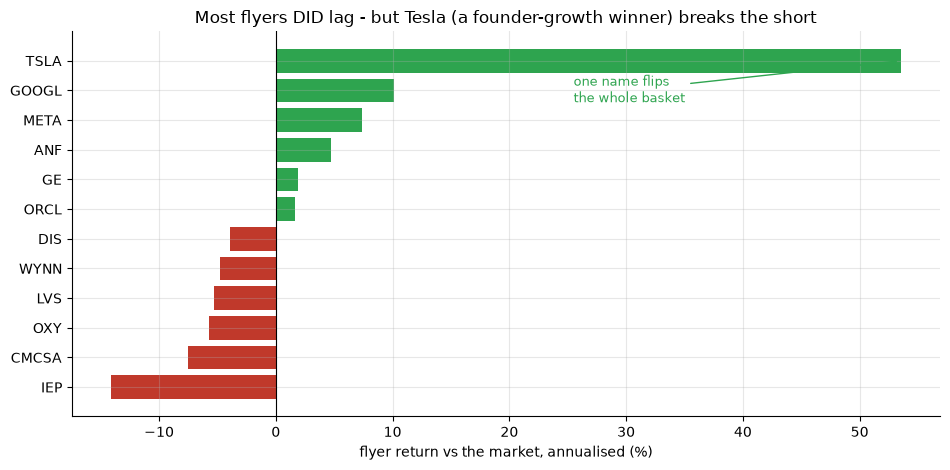

most flyers lag; TSLA +54%/yr, GOOGL +10%, META +7% drag the short basket UP


In [4]:
names = [n for n,_ in R['laggards']] + [n for n,_ in R['winners']]
vals  = [v for _,v in R['laggards']] + [v for _,v in R['winners']]
order = np.argsort(vals)
names = [names[i] for i in order]; vals = [vals[i] for i in order]
cols = [RED if v < 0 else GREEN for v in vals]
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.barh(names, vals, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('flyer return vs the market, annualised (%)')
ax.set_title('Most flyers DID lag - but Tesla (a founder-growth winner) breaks the short')
ax.annotate('one name flips\nthe whole basket', xy=(vals[-1], len(vals)-1),
            xytext=(vals[-1]-28, len(vals)-2.4), color=GREEN, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=GREEN))
plt.tight_layout(); plt.show()
print('most flyers lag; TSLA %+.0f%%/yr, GOOGL %+.0f%%, META %+.0f%% drag the short basket UP'
      % (R['winners'][0][1], R['winners'][1][1], R['winners'][2][1]))

There's the confound in one picture. Six of the flyers underperformed (IEP **-14%**, Comcast **-8%**, Occidental **-6%**…) — Yermack would be pleased. But the flyers who *survived and thrived* are **founder-led growth machines** — Tesla **+54%/yr**, Alphabet **+10%**, Meta **+7%**. Their jets are a footnote to a growth story. Shorting them for their aircraft would have cost you a fortune.

## 5 · The verdict

- **Signal — Weak.** The sign is right (frugal **16.1%** vs flyers **12.2%**; ex-mega-cap flyers lag the market **-3.8%/yr**, almost exactly Yermack's −4%) — and survivorship works *against* the claim, so it's not nothing. But the tradable spread is **HAC t = 0.47**, nowhere near significance. Real-as-a-sign, weak-as-a-signal.
- **Tradability — Mirage.** Net **+1.4%/yr** at *t* ≈ 0.5, and it's really a low-risk-vs-high-risk bet in disguise — one Tesla flips the short. Nothing to harvest.
- **"Governance discount?" — Misattributed.** The only significant number is the reward for being **short risky stocks and long safe ones** (a low-volatility premium), not for spotting bad governance. The jet rides along with the risk profile; it doesn't drive the return.

## 6 · Could you actually trade it? — the costs and the catch

Say you tried anyway. You'd rebalance monthly, pay to trade both legs, and — because you're shorting the flyers — pay a **borrow fee** to your broker. Here's the gross spread and what survives.

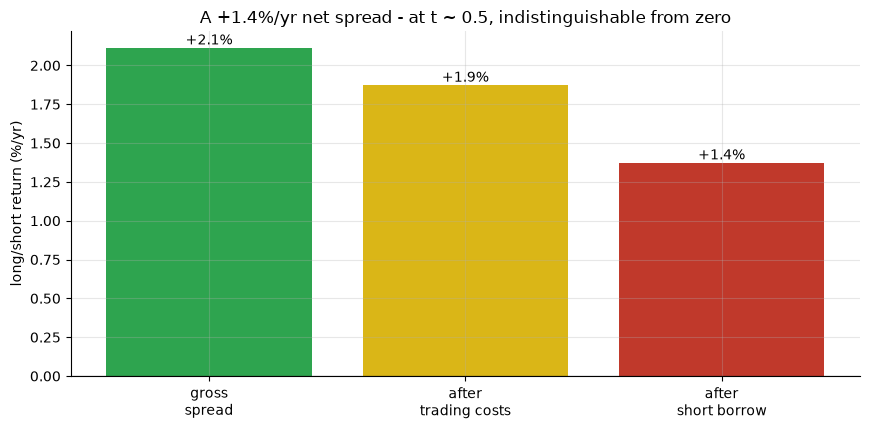

gross +2.1%  -costs 0.2  -borrow 0.5  = net +1.4%/yr (t~0.5)


In [5]:
if HAVE_REAL:
    nc = st.net_of_costs(PANEL['ls'])
    g, cst, bor, net = nc['gross_ann']*100, nc['rebal_cost_ann']*100, nc['borrow_ann']*100, nc['net_ann']*100
else:
    g, cst, bor, net = R['gross_ann'], R['cost_ann'], R['borrow_ann'], R['net_ann']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
labels = ['gross\nspread', 'after\ntrading costs', 'after\nshort borrow']
vals = [g, g-cst, g-cst-bor]; cols=[GREEN, AMBER, RED]
ax.bar(labels, vals, color=cols)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long/short return (%/yr)')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_title(f'A {net:+.1f}%/yr net spread - at t ~ 0.5, indistinguishable from zero')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%  -costs {cst:.1f}  -borrow {bor:.1f}  = net {net:+.1f}%/yr (t~0.5)')

Even before you argue about significance, there's only **+1.4%/yr** left — and it isn't real return, it's a low-volatility premium you could buy far more cheaply and reliably as an off-the-shelf factor, without betting the ranch on whether Elon Musk's next decade looks like his last. The jet angle adds single-name risk and subtracts nothing you were paid for.

## 7 · Going further 🛫

- **The governance-premium graveyard.** The famous [G-index] governance long/short (Gompers-Ishii-Metrick 2003) looked like huge alpha — then **decayed to zero** once the market learned it (Bebchuk-Cohen-Wang 2013). Our jet sort is the same shape: a governance story whose 'alpha' is really a risk factor.
- **Add back the dead.** The cleanest fix is the hardest: rebuild the heavy basket with the *delisted* abusers (Tyco, WorldCom, Enron, Chesapeake) using their real price paths to zero. That's where Yermack's discount would actually live — and it's exactly what a survivor tape can't show.
- **Neutralise the beta.** Re-run the long/short beta-hedged (or inside a low-vol-neutral universe) and see if *any* jet signal survives once the risk profile is matched.

*Think the jet is a real, tradable red flag? Show the long/short clearing **t = 2** on a window where the frugal and flyer baskets have the **same market beta** — then it isn't just betting-against-beta in a costume.*